In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

In [2]:
orders = pd.read_csv("C:/Users/rohit/Downloads/instacart/orders.csv")
order_products = pd.read_csv("C:/Users/rohit/Downloads/instacart/order_products__prior.csv")
products = pd.read_csv("C:/Users/rohit/Downloads/instacart/products.csv")
aisles = pd.read_csv("C:/Users/rohit/Downloads/instacart/aisles.csv")
departments = pd.read_csv("C:/Users/rohit/Downloads/instacart/departments.csv")

In [3]:
print(orders.shape)
print(order_products.shape)
print(products.shape)
print(aisles.shape)
print(departments.shape)

(3421083, 7)
(32434489, 4)
(49688, 4)
(134, 2)
(21, 2)


In [4]:
orders.head()

,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,prior,1,2,8,NaN
1,2398795,1,prior,2,3,7,15.0
2,473747,1,prior,3,3,12,21.0
3,2254736,1,prior,4,4,7,29.0
4,431534,1,prior,5,4,15,28.0


In [5]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3421083 entries, 0 to 3421082
Data columns (total 7 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   order_id                int64  
 1   user_id                 int64  
 2   eval_set                object 
 3   order_number            int64  
 4   order_dow               int64  
 5   order_hour_of_day       int64  
 6   days_since_prior_order  float64
dtypes: float64(1), int64(5), object(1)
memory usage: 182.7+ MB


In [6]:
orders.describe()

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
count,3.421083e+06,3.421083e+06,3.421083e+06,3.421083e+06,3.421083e+06,3.214874e+06
mean,1.710542e+06,1.029782e+05,1.715486e+01,2.776219e+00,1.345202e+01,1.111484e+01
std,9.875817e+05,5.953372e+04,1.773316e+01,2.046829e+00,4.226088e+00,9.206737e+00
min,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,8.552715e+05,5.139400e+04,5.000000e+00,1.000000e+00,1.000000e+01,4.000000e+00
50%,1.710542e+06,1.026890e+05,1.100000e+01,3.000000e+00,1.300000e+01,7.000000e+00
75%,2.565812e+06,1.543850e+05,2.300000e+01,5.000000e+00,1.600000e+01,1.500000e+01
max,3.421083e+06,2.062090e+05,1.000000e+02,6.000000e+00,2.300000e+01,3.000000e+01


In [7]:
products.head()


,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1
4,5,Green Chile Anytime Sauce,5,13


In [8]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49688 entries, 0 to 49687
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   product_id     49688 non-null  int64 
 1   product_name   49688 non-null  object
 2   aisle_id       49688 non-null  int64 
 3   department_id  49688 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.5+ MB


In [9]:
order_products.head()

,order_id,product_id,add_to_cart_order,reordered
0,2,33120,1,1
1,2,28985,2,1
2,2,9327,3,0
3,2,45918,4,1
4,2,30035,5,0


In [10]:
order_products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32434489 entries, 0 to 32434488
Data columns (total 4 columns):
 #   Column             Dtype
---  ------             -----
 0   order_id           int64
 1   product_id         int64
 2   add_to_cart_order  int64
 3   reordered          int64
dtypes: int64(4)
memory usage: 989.8 MB


In [11]:
orders.isnull().sum()

order_id                       0
user_id                        0
eval_set                       0
order_number                   0
order_dow                      0
order_hour_of_day              0
days_since_prior_order    206209
dtype: int64

In [12]:
df = order_products.merge(orders, on="order_id", how="left")

df = df.merge(products, on="product_id", how="left")

df = df.merge(aisles, on="aisle_id", how="left")

df = df.merge(departments, on="department_id", how="left")

In [13]:
df.head()

,order_id,product_id,add_to_cart_order,reordered,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_name,aisle_id,department_id,aisle,department
0,2,33120,1,1,202279,prior,3,5,9,8.0,Organic Egg Whites,86,16,eggs,dairy eggs
1,2,28985,2,1,202279,prior,3,5,9,8.0,Michigan Organic Kale,83,4,fresh vegetables,produce
2,2,9327,3,0,202279,prior,3,5,9,8.0,Garlic Powder,104,13,spices seasonings,pantry
3,2,45918,4,1,202279,prior,3,5,9,8.0,Coconut Butter,19,13,oils vinegars,pantry
4,2,30035,5,0,202279,prior,3,5,9,8.0,Natural Sweetener,17,13,baking ingredients,pantry


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 32434489 entries, 0 to 32434488
Data columns (total 15 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   order_id                int64  
 1   product_id              int64  
 2   add_to_cart_order       int64  
 3   reordered               int64  
 4   user_id                 int64  
 5   eval_set                object 
 6   order_number            int64  
 7   order_dow               int64  
 8   order_hour_of_day       int64  
 9   days_since_prior_order  float64
 10  product_name            object 
 11  aisle_id                int64  
 12  department_id           int64  
 13  aisle                   object 
 14  department              object 
dtypes: float64(1), int64(10), object(4)
memory usage: 3.9+ GB


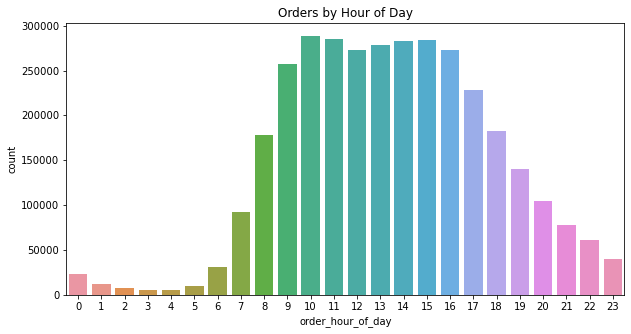

In [15]:
plt.figure(figsize=(10,5))

sns.countplot(x="order_hour_of_day", data=orders)

plt.title("Orders by Hour of Day")
plt.show()

**Insight**

Customer orders are concentrated during the **daytime hours**, with the highest activity between **10 AM and 3 PM**. Very few orders are placed late at night or early in the morning.

This suggests that most customers prefer to place grocery orders during normal daily hours rather than late-night shopping. From a business perspective, Instacart could allocate more delivery slots and staff during these peak hours to ensure faster deliveries and better customer experience.

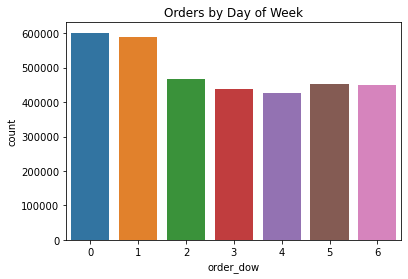

In [16]:
sns.countplot(x="order_dow", data=orders)
plt.title("Orders by Day of Week")
plt.show()

**Insight**

Order volume appears to be higher at the **beginning and end of the week**, with noticeable spikes around **Sunday and Monday**.

This likely reflects typical grocery shopping behavior, where customers either prepare for the upcoming week or restock after the weekend. Understanding these patterns can help the company optimize delivery capacity and promotional campaigns during high-demand days.

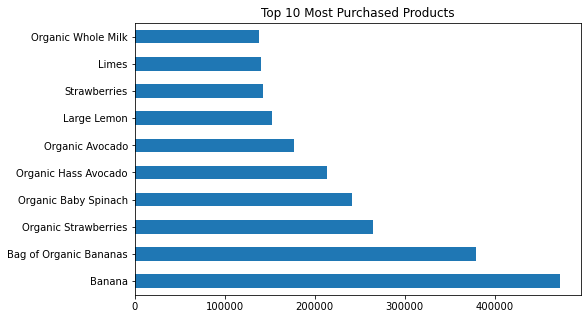

In [17]:
top_products = df['product_name'].value_counts().head(10)

top_products.plot(kind='barh', figsize=(8,5))

plt.title("Top 10 Most Purchased Products")
plt.show()

 **Insight**

Certain staple grocery items appear repeatedly among the most purchased products. These are typically everyday essentials that customers buy frequently.

The popularity of these items suggests strong demand for common household groceries. These products could be ideal candidates for promotions, subscription-style purchases, or recommendation algorithms that encourage repeat buying.

In [18]:
df['reordered'].mean()

0.5896974667922161

In [19]:
basket_size = df.groupby('order_id').size()

basket_size.describe()

count    3.214874e+06
mean     1.008888e+01
std      7.525398e+00
min      1.000000e+00
25%      5.000000e+00
50%      8.000000e+00
75%      1.400000e+01
max      1.450000e+02
dtype: float64

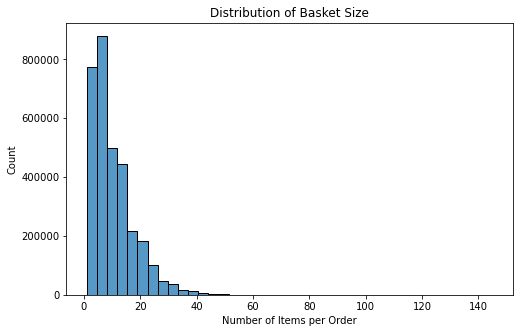

In [20]:
plt.figure(figsize=(8,5))

sns.histplot(basket_size, bins=40)

plt.title("Distribution of Basket Size")
plt.xlabel("Number of Items per Order")

plt.show()

**Insight**

Most orders contain a **small number of items**, typically between **5 and 10 products per order**. Very large baskets are relatively rare.

This suggests that customers often use Instacart for **quick grocery replenishment rather than large weekly shopping trips**. For the business, this insight can influence marketing strategies such as bundle recommendations or promotions that encourage customers to add more items to their cart.

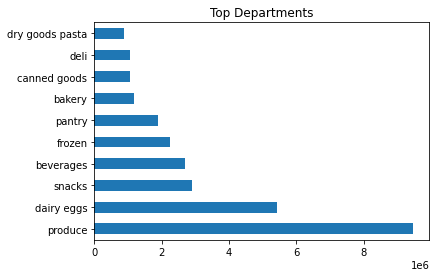

In [21]:
top_departments = df['department'].value_counts().head(10)

top_departments.plot(kind='barh')
plt.title("Top Departments")
plt.show()

**Insight**

The **produce department** dominates the number of purchased items, followed by other everyday grocery categories such as dairy, snacks, and beverages.

This indicates that fresh groceries are a major driver of demand on the platform. Since produce items are purchased frequently and have shorter shelf lives, they likely contribute significantly to repeat orders and customer retention.

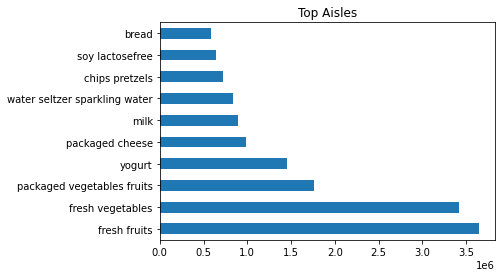

In [22]:
top_aisles = df['aisle'].value_counts().head(10)

top_aisles.plot(kind='barh')
plt.title("Top Aisles")
plt.show()

**Insight**

Aisles related to **fresh fruits, fresh vegetables, and packaged vegetables** appear among the most frequently ordered categories.

This further reinforces the importance of fresh food products on the platform. Customers are not only ordering packaged groceries but are heavily relying on Instacart for fresh produce as well. Maintaining strong inventory availability in these aisles would be critical for meeting customer demand.

In [23]:
df['reordered'].mean()

0.5896974667922161

**Insight**

A large percentage of products in the dataset are marked as **reordered**, indicating that many customers purchase the same items multiple times.

This suggests strong customer loyalty and predictable purchasing patterns. From a business perspective, reorder behavior is extremely valuable because it enables the company to build personalized recommendations and improve product suggestions based on a customer’s purchase history.

In [24]:
orders['days_since_prior_order'].describe()

count    3.214874e+06
mean     1.111484e+01
std      9.206737e+00
min      0.000000e+00
25%      4.000000e+00
50%      7.000000e+00
75%      1.500000e+01
max      3.000000e+01
Name: days_since_prior_order, dtype: float64

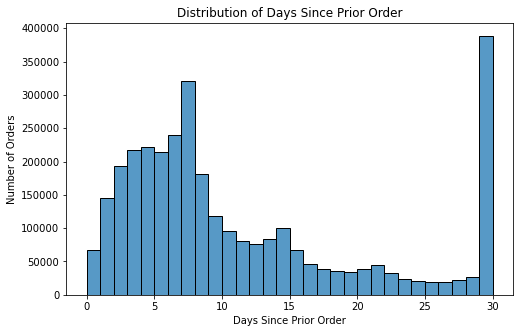

In [25]:
plt.figure(figsize=(8,5))
sns.histplot(orders['days_since_prior_order'].dropna(), bins=30)

plt.title("Distribution of Days Since Prior Order")
plt.xlabel("Days Since Prior Order")
plt.ylabel("Number of Orders")

plt.show()

**Insight**

Most repeat orders are placed within a relatively short time gap, with many customers returning within the first few weeks. The distribution also shows a noticeable concentration around common reorder intervals, suggesting that grocery shopping follows a fairly regular routine for many users.

This indicates that customer demand is not random. Many users appear to reorder on a recurring schedule, which could help Instacart improve demand forecasting, personalize reminders, and optimize promotional timing.

In [26]:
orders_per_user = orders.groupby('user_id')['order_number'].max()

orders_per_user.describe()

count    206209.000000
mean         16.590367
std          16.654774
min           4.000000
25%           6.000000
50%          10.000000
75%          20.000000
max         100.000000
Name: order_number, dtype: float64

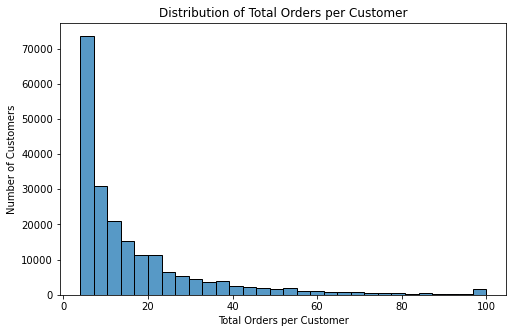

In [27]:
plt.figure(figsize=(8,5))

sns.histplot(orders_per_user, bins=30)

plt.title("Distribution of Total Orders per Customer")
plt.xlabel("Total Orders per Customer")
plt.ylabel("Number of Customers")

plt.show()

**Insight**

The distribution shows that while some customers place only a few orders, a significant portion of users return multiple times and place many orders on the platform.

This suggests that Instacart has a mix of occasional users and highly loyal customers. Identifying and retaining these frequent users is important because repeat customers typically contribute a large share of overall revenue.

In [28]:
dept_reorder = df.groupby('department')['reordered'].mean().sort_values(ascending=False)

dept_reorder.head(10)

department
dairy eggs    0.669969
beverages     0.653460
produce       0.649913
bakery        0.628141
deli          0.607719
pets          0.601285
babies        0.578971
bulk          0.577040
snacks        0.574180
alcohol       0.569924
Name: reordered, dtype: float64

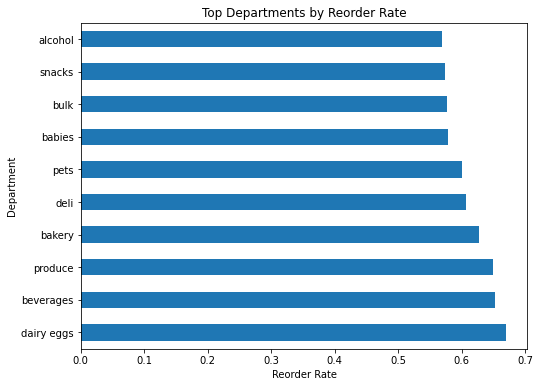

In [29]:
plt.figure(figsize=(8,6))

dept_reorder.head(10).plot(kind='barh')

plt.title("Top Departments by Reorder Rate")
plt.xlabel("Reorder Rate")
plt.ylabel("Department")

plt.show()

**Insight**

The **Dairy & Eggs department shows the highest reorder rate**, indicating that customers frequently repurchase items from this category.

Products like milk, eggs, butter, and yogurt are everyday household essentials that are consumed regularly and need frequent replenishment. Because of this, these products naturally generate a high number of repeat purchases.

From a business perspective, departments with high reorder rates are especially valuable because they drive consistent customer engagement and predictable demand.

In [30]:
reordered_products = df[df['reordered'] == 1]['product_name'].value_counts().head(10)

reordered_products

Banana                    398609
Bag of Organic Bananas    315913
Organic Strawberries      205845
Organic Baby Spinach      186884
Organic Hass Avocado      170131
Organic Avocado           134044
Organic Whole Milk        114510
Large Lemon               106255
Organic Raspberries       105409
Strawberries               99802
Name: product_name, dtype: int64

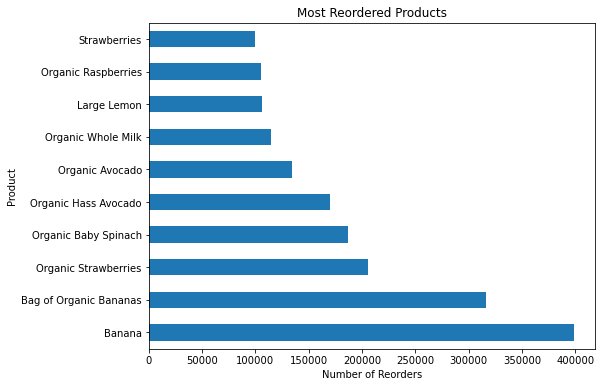

In [31]:
plt.figure(figsize=(8,6))

reordered_products.plot(kind='barh')

plt.title("Most Reordered Products")
plt.xlabel("Number of Reorders")
plt.ylabel("Product")

plt.show()

**Insight**

Bananas appear as the most frequently reordered product, followed closely by organic bananas. This suggests that fresh fruit is a staple item in many customers' grocery baskets and is purchased repeatedly.

The strong presence of bananas and other fresh produce items among the top reordered products indicates that customers rely on Instacart not only for packaged groceries but also for regularly replenishing fresh food. Ensuring consistent availability of these high-demand items is important for maintaining customer satisfaction and repeat purchases.

In [32]:
hourly_reorder = df.groupby('order_hour_of_day')['reordered'].mean()

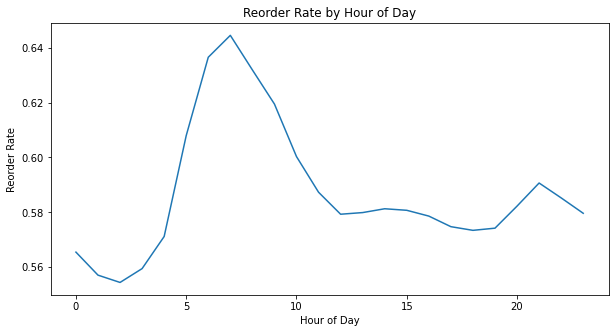

In [33]:
plt.figure(figsize=(10,5))

hourly_reorder.plot()

plt.title("Reorder Rate by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Reorder Rate")

plt.show()

**Insight**

The reorder rate appears to be slightly higher during the early morning hours, particularly between **5 AM and 10 AM**. This suggests that customers placing orders earlier in the day may be more likely to reorder familiar items rather than explore new products.

One possible explanation is that early orders may represent routine grocery restocking, where customers quickly reorder items they purchase regularly. Understanding this behavior could help improve features like "Buy Again" recommendations during peak reorder times.

In [34]:
orders['days_since_prior_order'].mean()

11.114836226863012

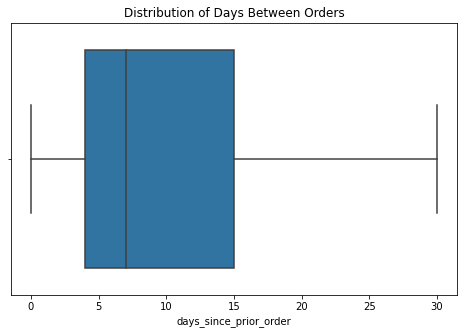

In [35]:
plt.figure(figsize=(8,5))

sns.boxplot(x=orders['days_since_prior_order'])

plt.title("Distribution of Days Between Orders")

plt.show()

**Insight**

The average time between two consecutive orders is approximately **11 days**, indicating that many customers return to place new grocery orders roughly every one to two weeks.

This suggests that Instacart is commonly used for **regular household grocery replenishment rather than occasional shopping**. Because customer demand follows a fairly predictable cycle, the company could potentially increase engagement by sending reminders or personalized promotions around the time when users are likely to place their next order.

In [38]:
df_sample = df.sample(200000, random_state=42)

In [39]:
df_sample.to_csv("instacart_powerbi_dataset.csv", index=False)

**Conclusion**

The exploratory data analysis revealed several important insights about customer purchasing behavior on the Instacart platform.

Most orders occur during daytime hours and early in the week, suggesting predictable grocery shopping patterns. Fresh produce dominates overall purchases, highlighting the importance of perishable items in driving demand. Additionally, a significant proportion of products are reordered, indicating strong customer loyalty and recurring purchasing habits.

Customers typically place orders approximately every 11 days, which suggests that the platform is commonly used for regular grocery replenishment rather than occasional shopping.

These insights can help improve inventory planning, recommendation systems, and promotional strategies to better match customer shopping behavior.